# Alzheimer's Disease Brain MRI — Multi-Class Tissue Segmentation
## FCN-32s / FCN-16s / FCN-8s | 4-Class (Background / CSF / Grey Matter / White Matter) | IBSR Dataset

**Dataset:** Internet Brain Segmentation Repository (IBSR) — 18 subjects, expert-annotated tri-class tissue segmentation (`segTRI`).

**Architecture:** Fully Convolutional Network (FCN) with VGG16 backbone. Implements all three standard FCN variants:
- **FCN-32s** — single 32× upsampling from the bottleneck (coarsest)
- **FCN-16s** — fuses pool4 skip + 2× upsampled bottleneck, then 16× upsample
- **FCN-8s** — additionally fuses pool3 skip for finest predictions (used as final model)

**Why multi-class directly:** Same reasoning as prior notebooks — IBSR `segTRI` uses the 4-label convention (0=BG, 1=CSF, 2=GM, 3=WM).

**Note:** EarlyStopping disabled — model trains for the full configured epochs.

**Note on CSF class:** IBSR's CSF label is far sparser (~0.17% of voxels) — expect CSF IoU to be noisier due to extreme class imbalance.


## 1. Import Libraries

In [1]:
import os
import cv2
import random
import shutil
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, Add, Dropout,
    BatchNormalization, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))


2026-06-30 06:02:45.677028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782799365.881384      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782799365.934261      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782799366.401664      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782799366.401718      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782799366.401723      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration & Extraction

In [2]:
# ─── Paths ────────────────────────────────────────────────────────────────────
IBSR_TGZ_PATH = '/kaggle/input/datasets/maheswarimudadla/ibsr-dataset/IBSR_V2.0_nifti_stripped.tgz'
EXTRACT_DIR   = '/kaggle/working/ibsr_extracted'
IBSR_ROOT     = os.path.join(EXTRACT_DIR, 'IBSR_nifti_stripped')

PROCESSED_DIR   = 'ibsr_processed'
IMAGE_FOLDER    = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER     = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR   = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR  = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR    = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR   = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.15
NUM_CLASSES = 4   # 0=background, 1=CSF, 2=Grey Matter, 3=White Matter
CLASS_NAMES = ['Background', 'CSF', 'Grey Matter', 'White Matter']

print('Config set ✓')


Config set ✓


In [3]:
if not os.path.exists(IBSR_ROOT):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print('Extracting IBSR archive...')
    with tarfile.open(IBSR_TGZ_PATH, 'r:gz') as tar:
        tar.extractall(path=EXTRACT_DIR)
    print('Extraction done ✓')
else:
    print('Already extracted ✓')

subject_folders = sorted([
    d for d in os.listdir(IBSR_ROOT)
    if os.path.isdir(os.path.join(IBSR_ROOT, d)) and d.startswith('IBSR_')
])
print(f'Found {len(subject_folders)} subjects: {subject_folders}')


Extracting IBSR archive...
Extraction done ✓
Found 18 subjects: ['IBSR_01', 'IBSR_02', 'IBSR_03', 'IBSR_04', 'IBSR_05', 'IBSR_06', 'IBSR_07', 'IBSR_08', 'IBSR_09', 'IBSR_10', 'IBSR_11', 'IBSR_12', 'IBSR_13', 'IBSR_14', 'IBSR_15', 'IBSR_16', 'IBSR_17', 'IBSR_18']


## 3. Extract 2D Slices — Keep All 4 Tissue Labels

In [4]:
def make_dir(path):
    os.makedirs(path, exist_ok=True)

for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    make_dir(d)

print('Directories ready ✓')


Directories ready ✓


In [5]:
def normalize_slice(arr):
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)

def extract_slices_ibsr(subject_dir, subject_name, img_out, mask_out, step=1):
    brain_path = os.path.join(subject_dir, f'{subject_name}_ana_strip.nii.gz')
    seg_path   = os.path.join(subject_dir, f'{subject_name}_segTRI_ana.nii')
    if not os.path.exists(brain_path) or not os.path.exists(seg_path):
        print(f'  Skipping {subject_name} — missing file(s)')
        return 0
    brain_vol = np.squeeze(nib.load(brain_path).get_fdata())
    seg_vol   = np.squeeze(nib.load(seg_path).get_fdata())
    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]
        if b_sl.max() == 0:
            continue
        img_arr  = normalize_slice(b_sl)
        mask_arr = np.round(seg_sl).astype(np.uint8)
        mask_arr = np.clip(mask_arr, 0, NUM_CLASSES - 1)
        fname = f'{subject_name}_sl{i:03d}.png'
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1
    return saved

for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

total_slices = 0
for subj_name in tqdm(subject_folders, desc='Extracting slices'):
    subj_dir = os.path.join(IBSR_ROOT, subj_name)
    total_slices += extract_slices_ibsr(subj_dir, subj_name, IMAGE_FOLDER, MASK_FOLDER, step=1)

print(f'Total slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')


Extracting slices:   0%|          | 0/18 [00:00<?, ?it/s]

  Skipping IBSR_02 — missing file(s)
  Skipping IBSR_03 — missing file(s)
  Skipping IBSR_04 — missing file(s)
  Skipping IBSR_05 — missing file(s)
  Skipping IBSR_07 — missing file(s)
  Skipping IBSR_08 — missing file(s)
  Skipping IBSR_09 — missing file(s)
  Skipping IBSR_10 — missing file(s)
  Skipping IBSR_11 — missing file(s)
  Skipping IBSR_12 — missing file(s)
  Skipping IBSR_13 — missing file(s)
  Skipping IBSR_14 — missing file(s)
  Skipping IBSR_15 — missing file(s)
  Skipping IBSR_16 — missing file(s)
  Skipping IBSR_17 — missing file(s)
  Skipping IBSR_18 — missing file(s)
Total slices extracted : 236
Images saved           : 236
Masks  saved           : 236


## 4. Verify Label Distribution & Visualize

In [6]:
sample_mask_files = random.sample(os.listdir(MASK_FOLDER), min(20, len(os.listdir(MASK_FOLDER))))
all_vals = set()
for f in sample_mask_files:
    m = cv2.imread(os.path.join(MASK_FOLDER, f), cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())
print('Unique label values found across sample masks:', sorted(all_vals))
print('Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)')


Unique label values found across sample masks: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)


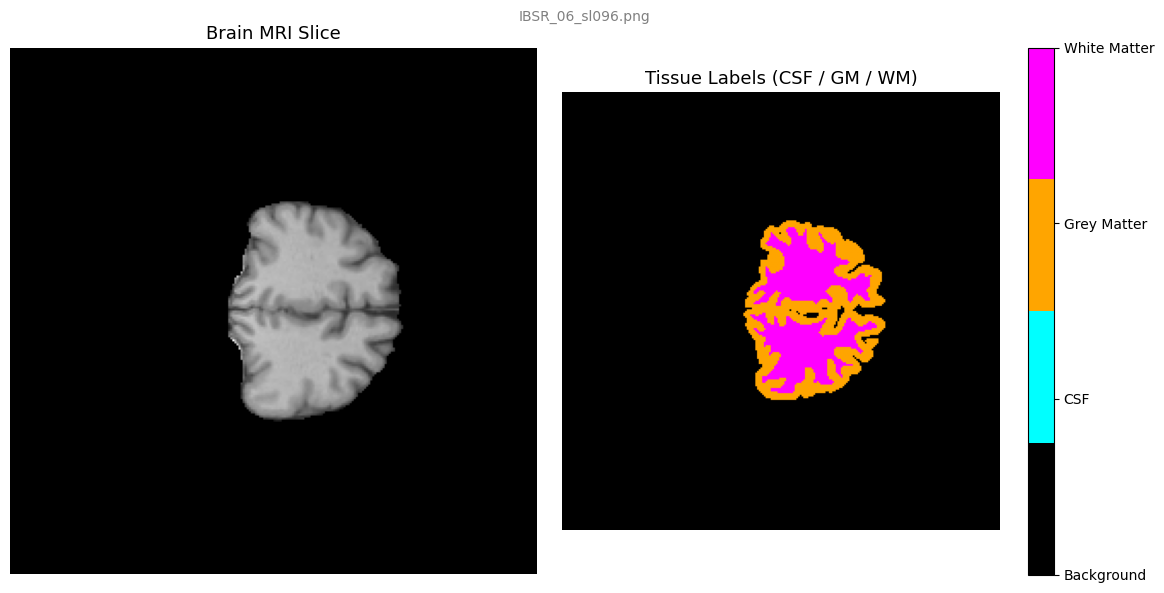

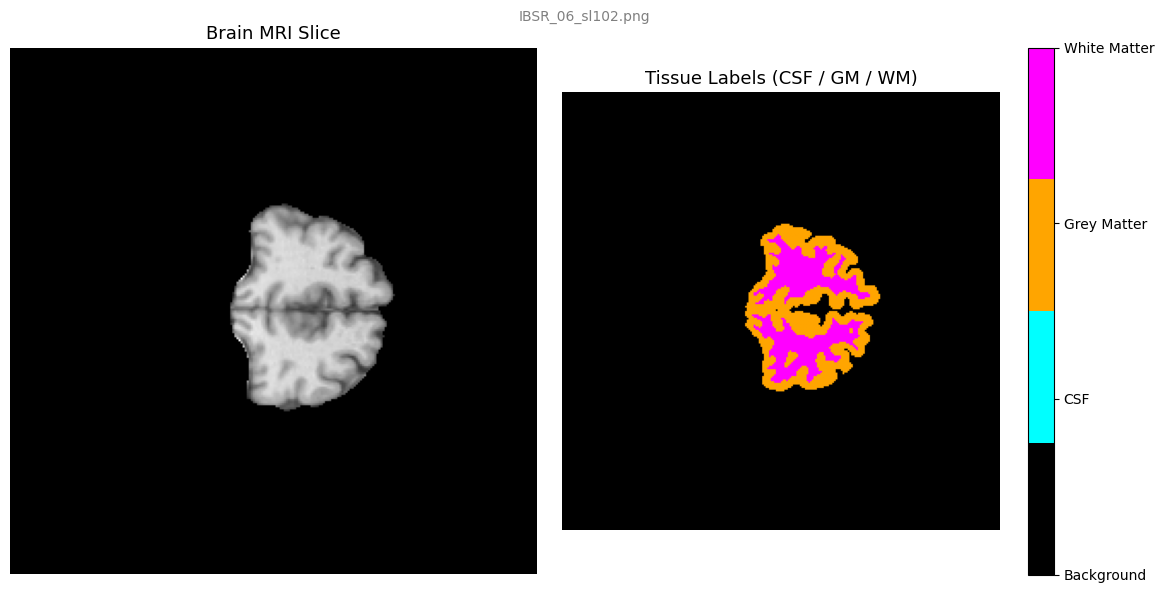

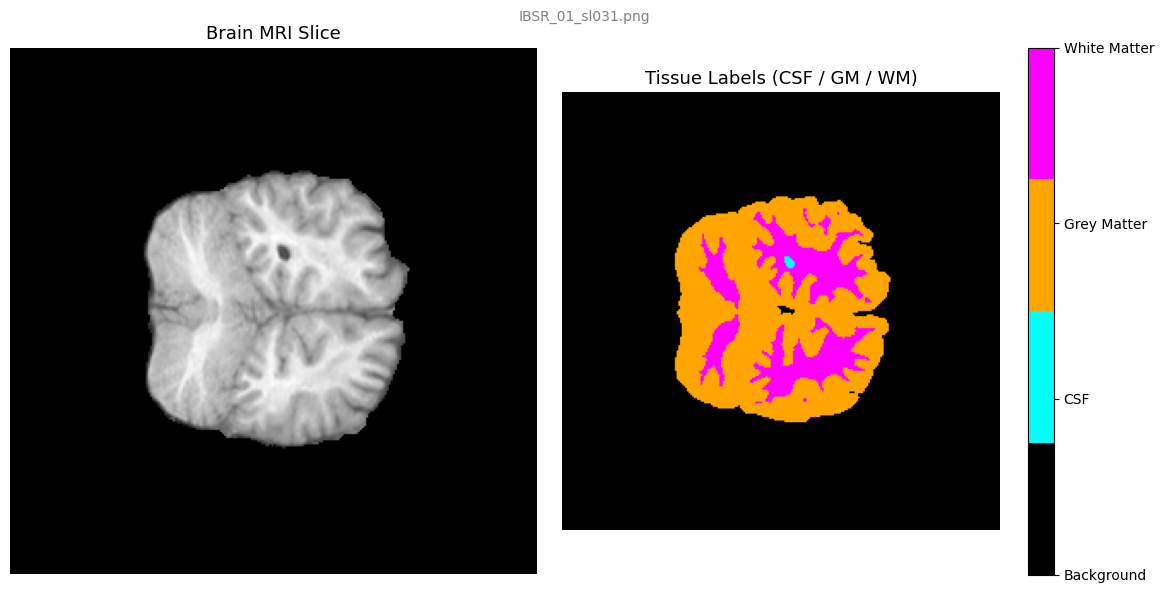

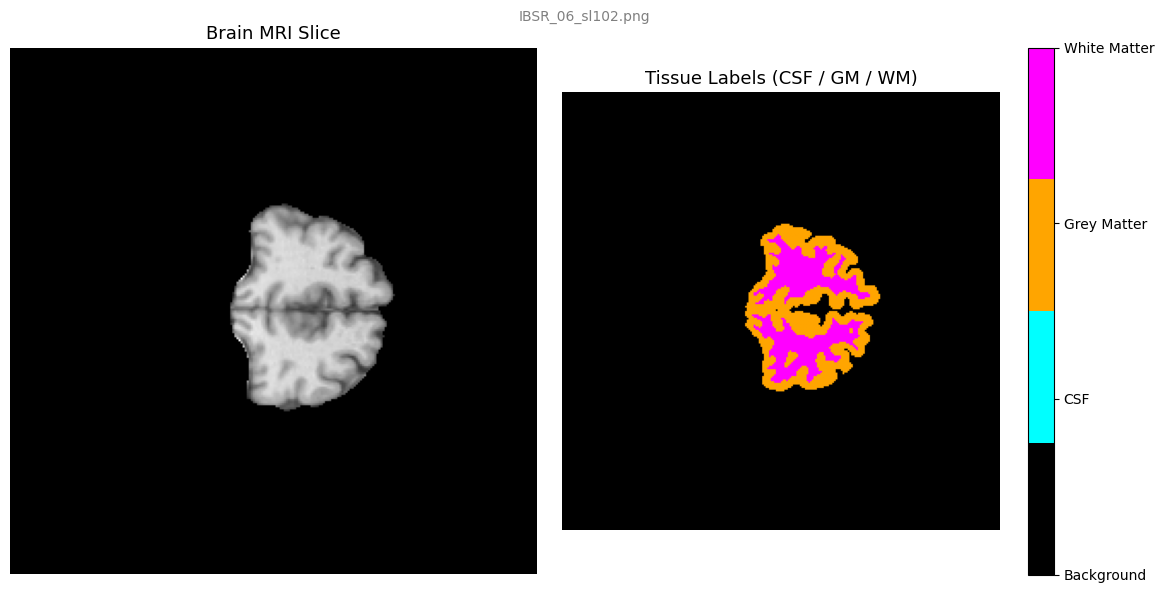

In [7]:
CLASS_COLORS = ['black', 'cyan', 'orange', 'magenta']
cmap_classes = mcolors.ListedColormap(CLASS_COLORS)

def visualize_sample_multiclass(image_name, img_dir=IMAGE_FOLDER, mask_dir=MASK_FOLDER):
    img  = cv2.imread(os.path.join(img_dir,  image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_dir, image_name), cv2.IMREAD_GRAYSCALE)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img, cmap='gray'); axes[0].set_title('Brain MRI Slice', fontsize=13)
    im = axes[1].imshow(mask, cmap=cmap_classes, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title('Tissue Labels (CSF / GM / WM)', fontsize=13)
    cbar = plt.colorbar(im, ax=axes[1], ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)
    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout(); plt.show()

all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample_multiclass(random.choice(all_images))


## 5. Train / Test Split

In [8]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])
assert images == masks, 'Image-mask mismatch!'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')


Train: 200  |  Test: 36


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline — one-hot encoded masks

In [9]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES)
    mask = tf.cast(mask, tf.float32)
    return img, mask

def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask

def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)
print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes →  images:', imgs.shape, ' masks:', masks.shape)


I0000 00:00:1782799388.061453      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes →  images: (16, 224, 224, 3)  masks: (16, 224, 224, 4)


## 7. Model — FCN-8s with VGG16 Backbone, 4-class softmax output

**FCN variants summary:**
- **FCN-32s** — replaces VGG16 FC layers with 1×1 convolutions (score map), then a single 32× bilinear transposed convolution to full resolution. Coarsest predictions.
- **FCN-16s** — adds a 2× upsampling of the bottleneck score, fuses it with a pool4 score map, then 16× upsamples. Finer predictions.
- **FCN-8s** — additionally fuses a pool3 score map after another 2× upsampling, then 8× upsamples. Finest predictions — used as the final model.

All score maps use 1×1 convolutions with `num_classes` filters. Fusion is element-wise addition. Final upsampling uses `Conv2DTranspose` with bilinear initialisation.


In [10]:
def bilinear_upsample_weights(factor, num_classes):
    """
    Compute bilinear upsampling kernel for Conv2DTranspose initialisation.
    Matches the original FCN paper's upsampling strategy.
    """
    filter_size = 2 * factor - factor % 2
    center = factor - (1 if factor % 2 == 1 else 0.5)
    og = np.ogrid[:filter_size, :filter_size]
    kernel_2d = (1 - abs(og[0] - center) / factor) * (1 - abs(og[1] - center) / factor)
    weights = np.zeros((filter_size, filter_size, num_classes, num_classes), dtype=np.float32)
    for c in range(num_classes):
        weights[:, :, c, c] = kernel_2d
    return weights

def build_fcn8s_multiclass(input_shape=(224, 224, 3), num_classes=4, freeze_encoder=True):
    """
    FCN-8s for multi-class segmentation using VGG16 backbone.

    VGG16 feature maps used:
      pool3  ->  28x28  256 ch  (stride 8 from input)
      pool4  ->  14x14  512 ch  (stride 16)
      pool5  ->   7x7   512 ch  (stride 32, bottleneck)

    For 224x224 input:
      pool3 = 28x28, pool4 = 14x14, pool5 = 7x7
    """
    inputs = Input(shape=input_shape, name='input')
    base   = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)
    if freeze_encoder:
        for layer in base.layers:
            layer.trainable = False
    # Encoder feature maps
    pool3 = base.get_layer('block3_pool').output  # 28x28, 256
    pool4 = base.get_layer('block4_pool').output  # 14x14, 512
    pool5 = base.get_layer('block5_pool').output  #  7x7,  512
    # ── FCN head: replace FC layers with 1x1 convolutions ────────────────────
    # Bottleneck score (from pool5)
    x = Conv2D(4096, (7, 7), activation='relu', padding='same', name='fc6')(pool5)
    x = Dropout(0.5, name='drop6')(x)
    x = Conv2D(4096, (1, 1), activation='relu', padding='same', name='fc7')(x)
    x = Dropout(0.5, name='drop7')(x)
    score32 = Conv2D(num_classes, (1, 1), padding='same', name='score_pool5')(x)
    # Pool4 score
    score_pool4 = Conv2D(num_classes, (1, 1), padding='same', name='score_pool4')(pool4)
    # Pool3 score
    score_pool3 = Conv2D(num_classes, (1, 1), padding='same', name='score_pool3')(pool3)
    # ── FCN-32s: 32x upsample from bottleneck ────────────────────────────────
    # (Not used as output but kept for intermediate reference)
    upscore32 = Conv2DTranspose(
        num_classes, kernel_size=(64, 64), strides=(32, 32),
        padding='same', use_bias=False, name='upscore32'
    )(score32)
    # ── FCN-16s: 2x upsample bottleneck, fuse pool4 ──────────────────────────
    upscore_pool5_2x = Conv2DTranspose(
        num_classes, kernel_size=(4, 4), strides=(2, 2),
        padding='same', use_bias=False, name='upscore_pool5_2x'
    )(score32)
    fuse16 = Add(name='fuse16')([upscore_pool5_2x, score_pool4])
    # ── FCN-8s: 2x upsample fuse16, fuse pool3, then 8x upsample ─────────────
    upscore_fuse16_2x = Conv2DTranspose(
        num_classes, kernel_size=(4, 4), strides=(2, 2),
        padding='same', use_bias=False, name='upscore_fuse16_2x'
    )(fuse16)
    fuse8 = Add(name='fuse8')([upscore_fuse16_2x, score_pool3])
    # Final 8x upsample to full resolution
    output = Conv2DTranspose(
        num_classes, kernel_size=(16, 16), strides=(8, 8),
        padding='same', use_bias=False, name='upscore_final'
    )(fuse8)
    output = Activation('softmax', name='output')(output)
    model = Model(inputs=inputs, outputs=output, name='FCN8s_MultiClass')
    return model

model = build_fcn8s_multiclass(
    input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES, freeze_encoder=True
)
print('Model built ✓')
print(f'Total parameters      : {model.count_params():,}')
print(f'Trainable parameters  : {sum([K.count_params(w) for w in model.trainable_weights]):,}')


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model built ✓
Total parameters      : 134,284,620
Trainable parameters  : 119,569,932


## 8. Custom Metrics & Loss — categorical versions

In [11]:
def dice_coefficient_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    return K.mean((2.0 * intersection + smooth) / (union + smooth))

def dice_loss_multiclass(y_true, y_pred):
    return 1.0 - dice_coefficient_multiclass(y_true, y_pred)

def iou_score_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    total = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0) - intersection
    return K.mean((intersection + smooth) / (total + smooth))

def csf_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 1]; p = y_pred[..., 1]
    i = K.sum(t * p); u = K.sum(t) + K.sum(p) - i
    return (i + smooth) / (u + smooth)

def gm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 2]; p = y_pred[..., 2]
    i = K.sum(t * p); u = K.sum(t) + K.sum(p) - i
    return (i + smooth) / (u + smooth)

def wm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 3]; p = y_pred[..., 3]
    i = K.sum(t * p); u = K.sum(t) + K.sum(p) - i
    return (i + smooth) / (u + smooth)

def pixel_accuracy_multiclass(y_true, y_pred):
    return K.mean(K.cast(K.equal(K.argmax(y_true, axis=-1), K.argmax(y_pred, axis=-1)), K.floatx()))

def combined_loss_multiclass(y_true, y_pred):
    return dice_loss_multiclass(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss_multiclass,
    metrics=[dice_coefficient_multiclass, iou_score_multiclass, pixel_accuracy_multiclass,
             csf_iou, gm_iou, wm_iou]
)
print('Model compiled ✓')


Model compiled ✓


## 9. Model Summary

In [12]:
model.summary()

try:
    tf.keras.utils.plot_model(
        model, to_file='fcn8s_multiclass_ibsr_architecture.png',
        show_shapes=True, show_layer_names=True, rankdir='TB', dpi=64
    )
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped:', str(e)[:150])


Model: "FCN8s_MultiClass"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 134,284,620 (512.26 MB)

 Trainable params: 119,569,932 (456.12 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Architecture diagram saved ✓


## 10. Callbacks (EarlyStopping disabled)

In [13]:
def decode_mask(onehot_mask):
    return tf.argmax(onehot_mask, axis=-1)

def colorize_mask(label_map):
    colors = np.array([[0,0,0],[0,255,255],[255,165,0],[255,0,255]], dtype=np.uint8)
    return colors[np.array(label_map).astype(int)]

def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            gt_labels   = decode_mask(masks[i]).numpy()
            pred_labels = decode_mask(preds[i]).numpy()
            fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
            axes[0].imshow(imgs[i].numpy());            axes[0].set_title('Input MRI')
            axes[1].imshow(colorize_mask(gt_labels));   axes[1].set_title('Ground Truth')
            axes[2].imshow(colorize_mask(pred_labels)); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout(); plt.show()

class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')

logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_fcn8s_multiclass_ibsr.keras', verbose=1,
                               save_best_only=True, monitor='val_iou_score_multiclass', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
]
print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')


Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1782799394.464727     132 service.cc:152] XLA service 0x7f473800cf00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782799394.464791     132 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782799394.686995     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782799402.517290     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


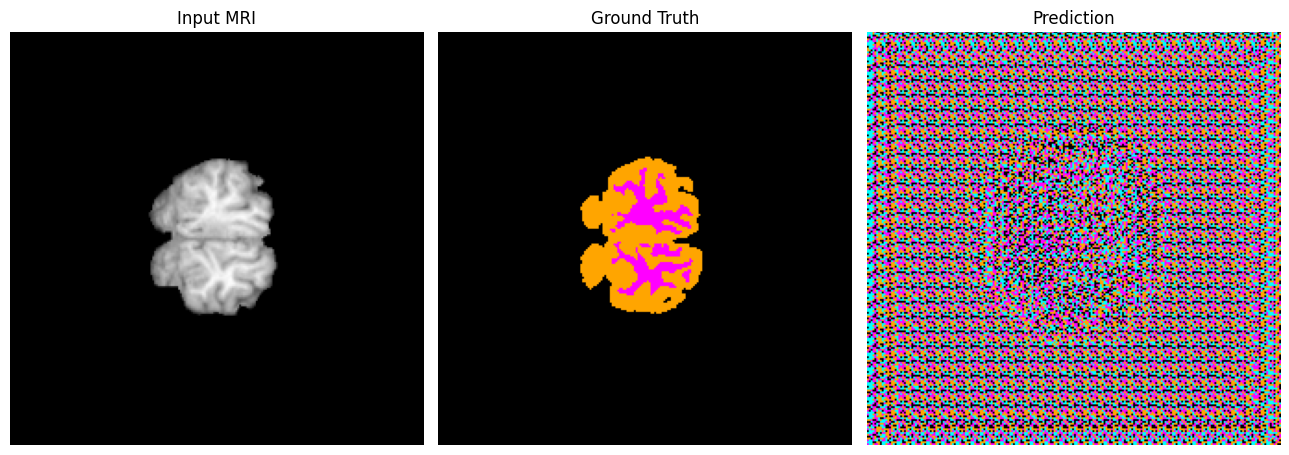

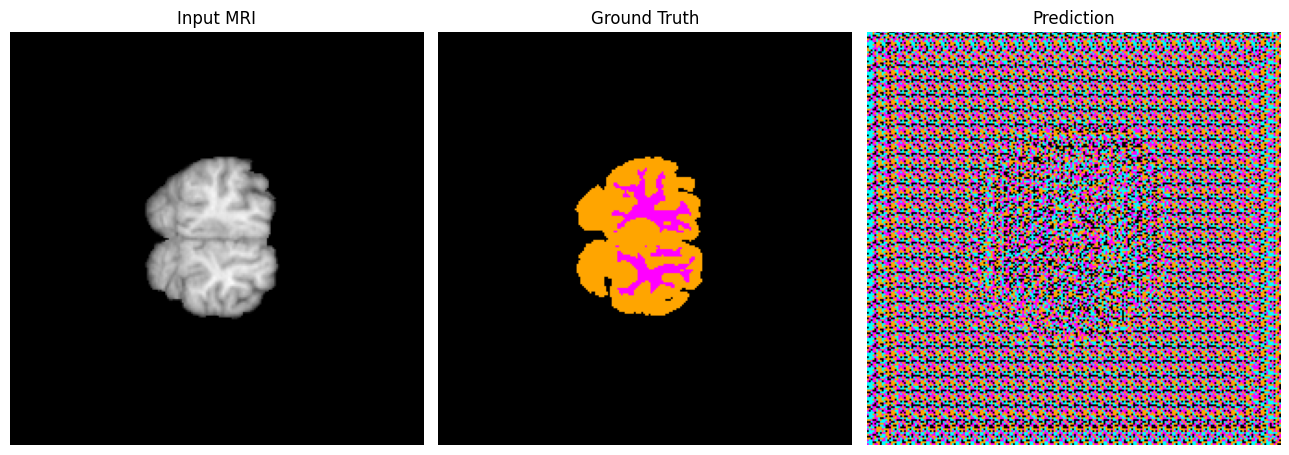

In [14]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)


## 12. Training

Steps per epoch  : 12
Validation steps : 2
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - csf_iou: 0.0019 - dice_coefficient_multiclass: 0.1435 - gm_iou: 0.0666 - iou_score_multiclass: 0.0839 - loss: 2.6770 - pixel_accuracy_multiclass: 0.2261 - wm_iou: 0.0400
Epoch 1: val_iou_score_multiclass improved from None to 0.09092, saving model to best_model_fcn8s_multiclass_ibsr.keras

Epoch 1: finished saving model to best_model_fcn8s_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - csf_iou: 0.0026 - dice_coefficient_multiclass: 0.1459 - gm_iou: 0.0628 - iou_score_multiclass: 0.0856 - loss: 2.6402 - pixel_accuracy_multiclass: 0.2359 - wm_iou: 0.0431 - val_csf_iou: 0.0021 - val_dice_coefficient_multiclass: 0.1538 - val_gm_iou: 0.0689 - val_iou_score_multiclass: 0.0909 - val_loss: 2.5454 - val_pixel_accuracy_multiclass: 0.2583 - val_wm_iou: 0.0432 - learning_rate: 1.0000e-04
Epoch 2/100
 1/12 ━━━━━━━━━━━━━━━━━━━━ 1:26 8s/step - csf_iou: 1.0395e-05 - dice_coefficient_multic

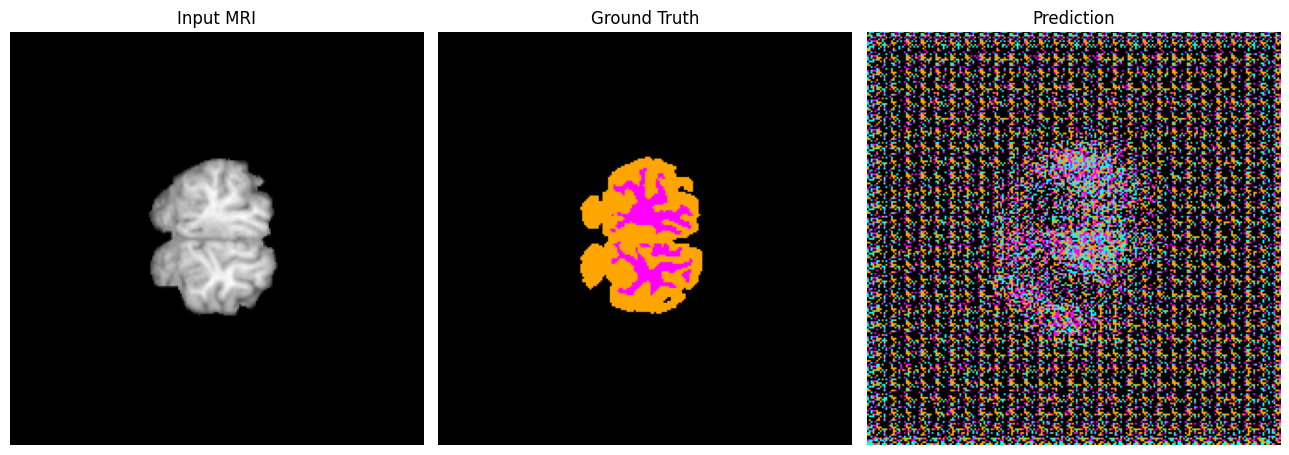

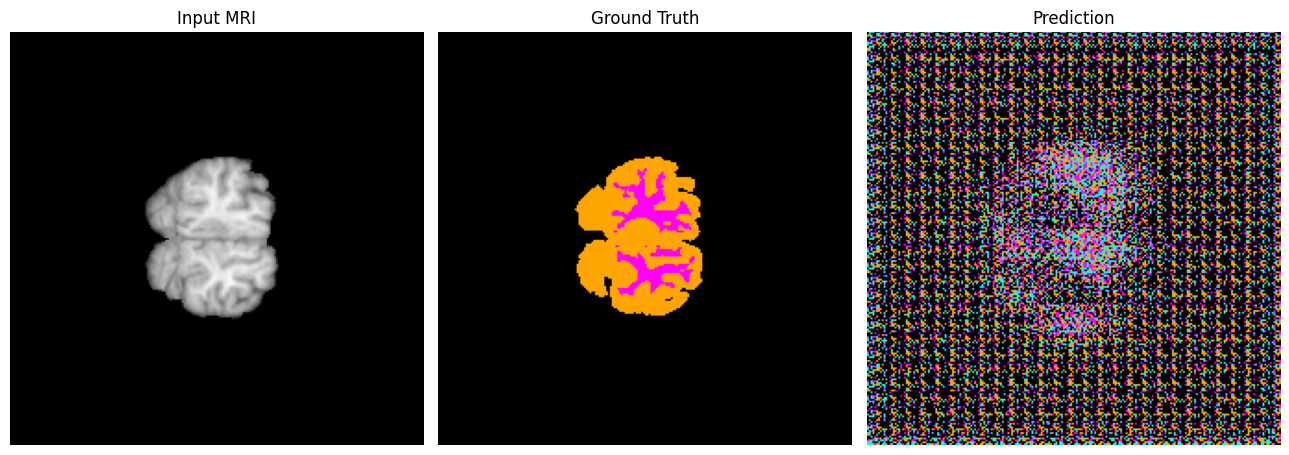

Prediction after epoch 10


Epoch 10: val_iou_score_multiclass improved from 0.13629 to 0.13774, saving model to best_model_fcn8s_multiclass_ibsr.keras

Epoch 10: finished saving model to best_model_fcn8s_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - csf_iou: 1.3871e-05 - dice_coefficient_multiclass: 0.1664 - gm_iou: 0.0195 - iou_score_multiclass: 0.1175 - loss: 1.8002 - pixel_accuracy_multiclass: 0.6362 - wm_iou: 0.0060 - val_csf_iou: 0.0026 - val_dice_coefficient_multiclass: 0.2084 - val_gm_iou: 0.0753 - val_iou_score_multiclass: 0.1377 - val_loss: 1.9332 - val_pixel_accuracy_multiclass: 0.5711 - val_wm_iou: 0.0484 - learning_rate: 1.0000e-04
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - csf_iou: 0.0025 - dice_coefficient_multiclass: 0.2093 - gm_iou: 0.0738 - iou_score_multiclass: 0.1402 - loss: 1.8920 - pixel_accuracy_multiclass: 0.5939 - wm_iou: 0.0448
Epoch 11: val_iou_score_multiclass improved from 0.13774 to 0.15638, saving model to best_model_fcn8s_mu

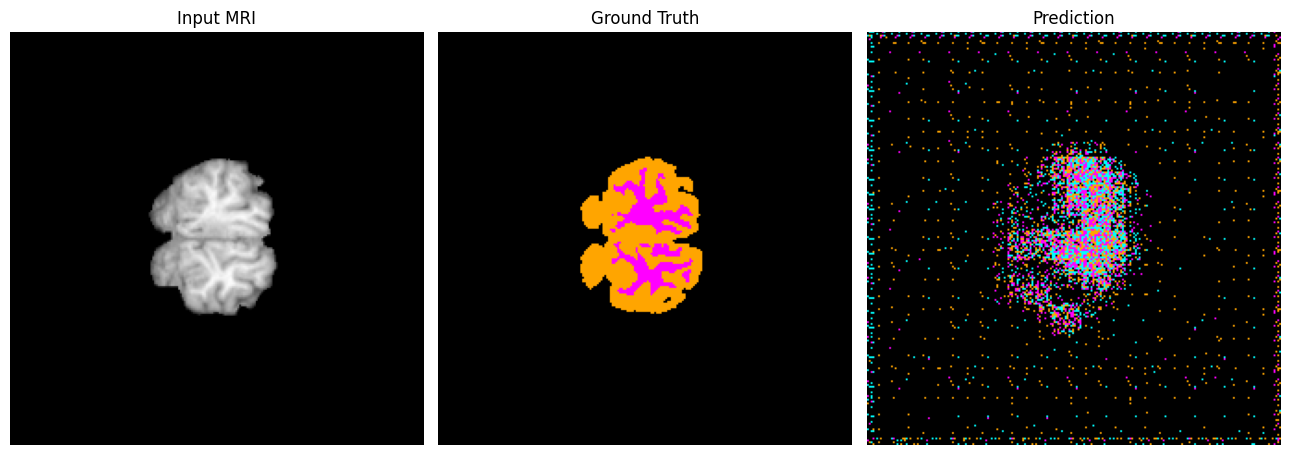

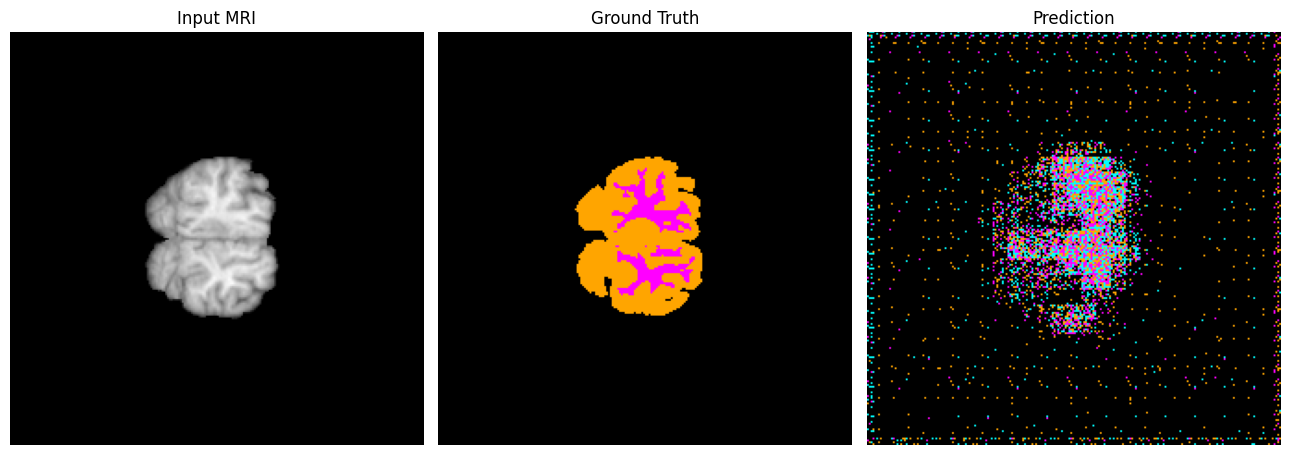

Prediction after epoch 20


Epoch 20: val_iou_score_multiclass improved from 0.25614 to 0.25775, saving model to best_model_fcn8s_multiclass_ibsr.keras

Epoch 20: finished saving model to best_model_fcn8s_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - csf_iou: 4.8353e-05 - dice_coefficient_multiclass: 0.2632 - gm_iou: 0.0483 - iou_score_multiclass: 0.2287 - loss: 0.9919 - pixel_accuracy_multiclass: 0.9419 - wm_iou: 0.0236 - val_csf_iou: 0.0069 - val_dice_coefficient_multiclass: 0.3295 - val_gm_iou: 0.1312 - val_iou_score_multiclass: 0.2578 - val_loss: 1.2033 - val_pixel_accuracy_multiclass: 0.8362 - val_wm_iou: 0.1061 - learning_rate: 1.0000e-04
Epoch 21/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - csf_iou: 0.0061 - dice_coefficient_multiclass: 0.3255 - gm_iou: 0.1274 - iou_score_multiclass: 0.2575 - loss: 1.1838 - pixel_accuracy_multiclass: 0.8429 - wm_iou: 0.0976
Epoch 21: val_iou_score_multiclass improved from 0.25775 to 0.27596, saving model to best_model_fcn8s_mu

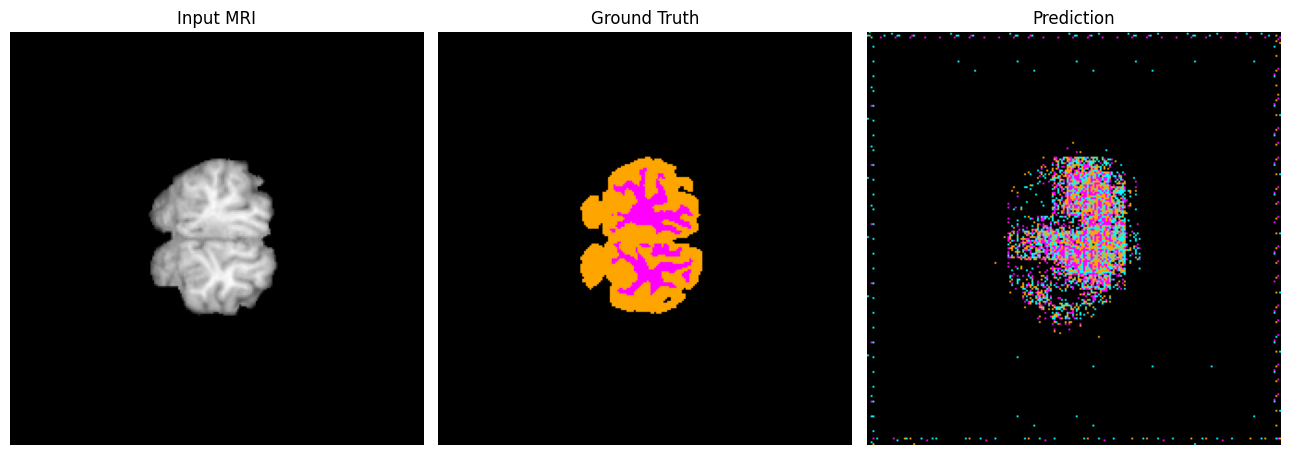

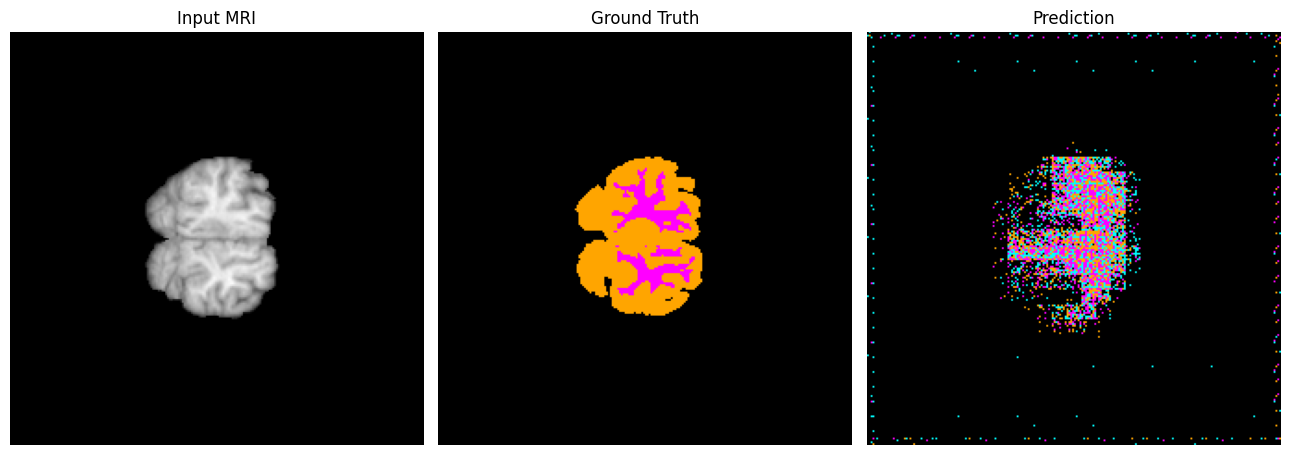

Prediction after epoch 30


Epoch 30: val_iou_score_multiclass did not improve from 0.31658
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - csf_iou: 1.2517e-04 - dice_coefficient_multiclass: 0.3375 - gm_iou: 0.1327 - iou_score_multiclass: 0.2903 - loss: 0.7744 - pixel_accuracy_multiclass: 0.9712 - wm_iou: 0.0750 - val_csf_iou: 0.0106 - val_dice_coefficient_multiclass: 0.3902 - val_gm_iou: 0.1870 - val_iou_score_multiclass: 0.3153 - val_loss: 0.9792 - val_pixel_accuracy_multiclass: 0.8728 - val_wm_iou: 0.1598 - learning_rate: 1.0000e-04
Epoch 31/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - csf_iou: 0.0081 - dice_coefficient_multiclass: 0.3840 - gm_iou: 0.1839 - iou_score_multiclass: 0.3115 - loss: 0.9794 - pixel_accuracy_multiclass: 0.8756 - wm_iou: 0.1499
Epoch 31: val_iou_score_multiclass improved from 0.31658 to 0.32674, saving model to best_model_fcn8s_multiclass_ibsr.keras

Epoch 31: finished saving model to best_model_fcn8s_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step -

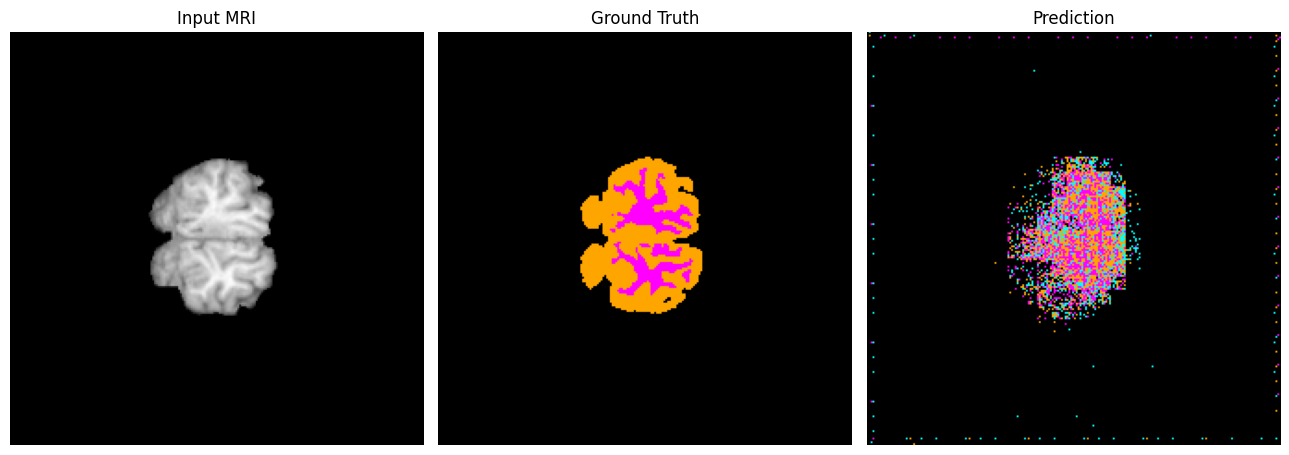

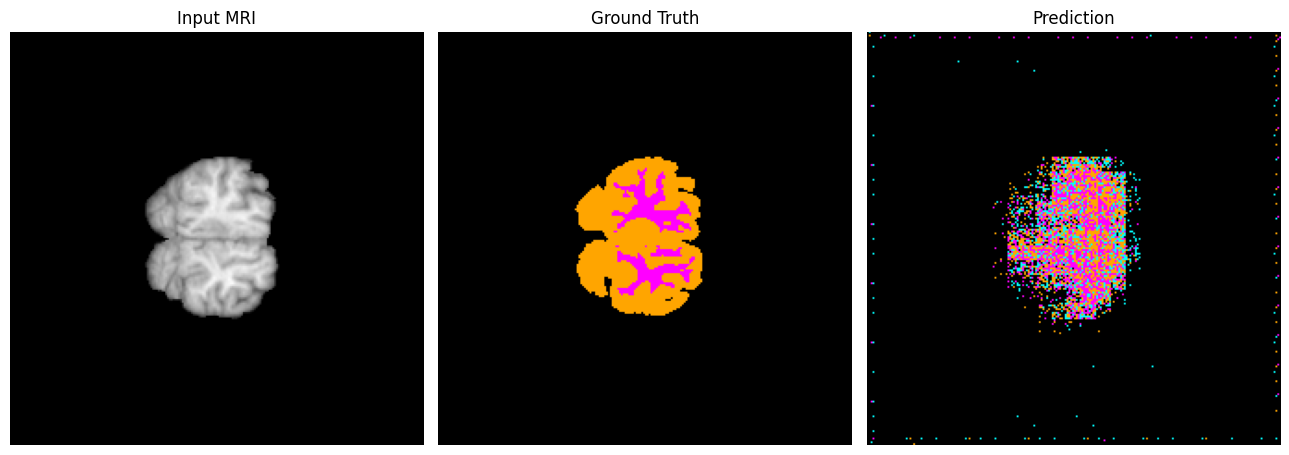

Prediction after epoch 40


Epoch 40: val_iou_score_multiclass did not improve from 0.34890
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - csf_iou: 1.8014e-04 - dice_coefficient_multiclass: 0.3838 - gm_iou: 0.2076 - iou_score_multiclass: 0.3236 - loss: 0.7002 - pixel_accuracy_multiclass: 0.9757 - wm_iou: 0.1146 - val_csf_iou: 0.0094 - val_dice_coefficient_multiclass: 0.4294 - val_gm_iou: 0.2505 - val_iou_score_multiclass: 0.3486 - val_loss: 0.8726 - val_pixel_accuracy_multiclass: 0.8898 - val_wm_iou: 0.1987 - learning_rate: 1.0000e-04
Epoch 41/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - csf_iou: 0.0064 - dice_coefficient_multiclass: 0.4255 - gm_iou: 0.2526 - iou_score_multiclass: 0.3467 - loss: 0.8681 - pixel_accuracy_multiclass: 0.8933 - wm_iou: 0.1897
Epoch 41: val_iou_score_multiclass improved from 0.34890 to 0.35371, saving model to best_model_fcn8s_multiclass_ibsr.keras

Epoch 41: finished saving model to best_model_fcn8s_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step -

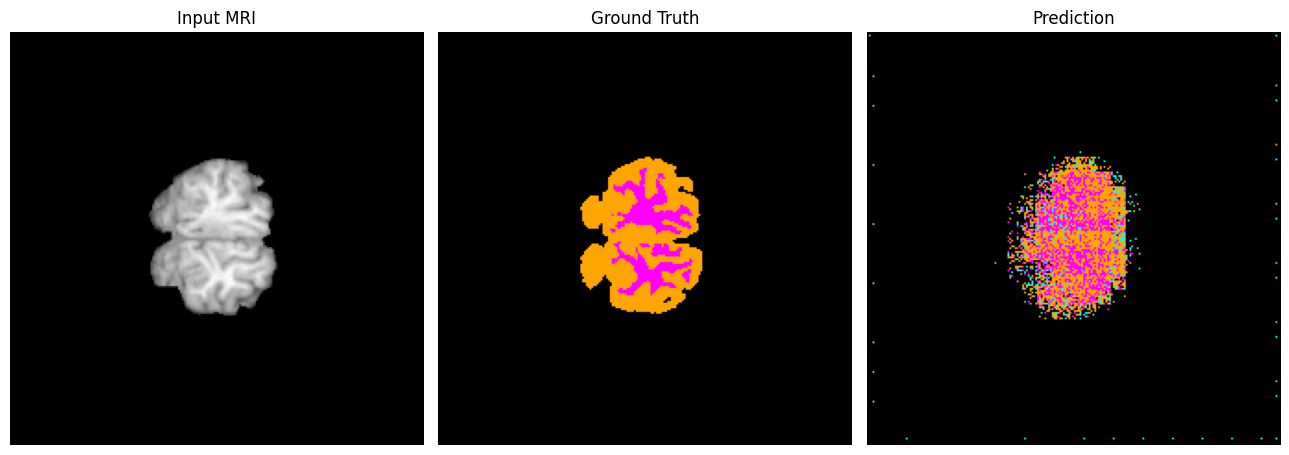

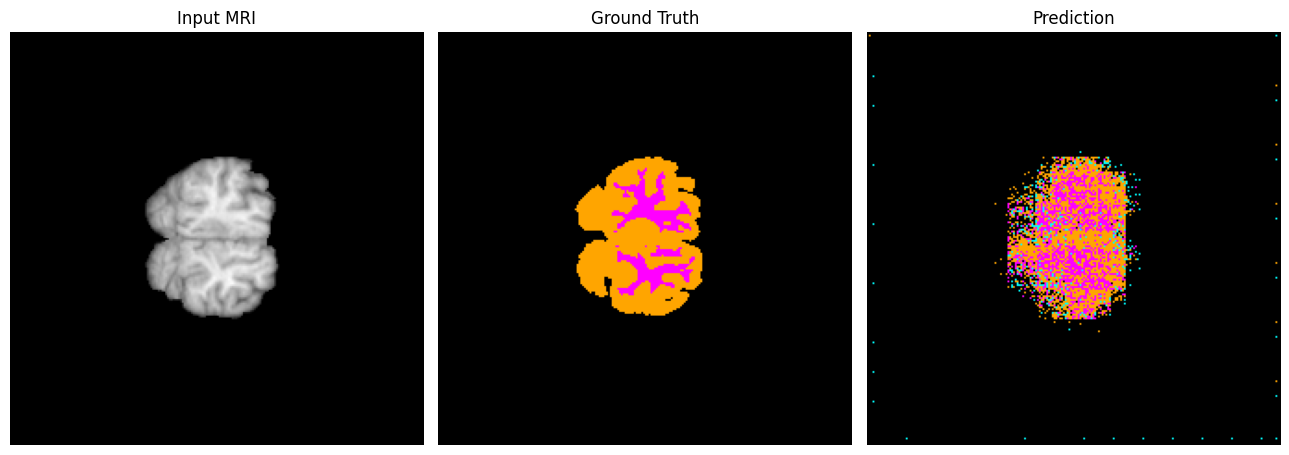

Prediction after epoch 60


Epoch 60: val_iou_score_multiclass improved from 0.38808 to 0.38825, saving model to best_model_fcn8s_multiclass_ibsr.keras

Epoch 60: finished saving model to best_model_fcn8s_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - csf_iou: 3.3635e-04 - dice_coefficient_multiclass: 0.4426 - gm_iou: 0.3413 - iou_score_multiclass: 0.3700 - loss: 0.6183 - pixel_accuracy_multiclass: 0.9817 - wm_iou: 0.1563 - val_csf_iou: 0.0073 - val_dice_coefficient_multiclass: 0.4741 - val_gm_iou: 0.3494 - val_iou_score_multiclass: 0.3883 - val_loss: 0.7520 - val_pixel_accuracy_multiclass: 0.9133 - val_wm_iou: 0.2392 - learning_rate: 1.0000e-04
Epoch 61/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - csf_iou: 0.0043 - dice_coefficient_multiclass: 0.4726 - gm_iou: 0.3565 - iou_score_multiclass: 0.3884 - loss: 0.7429 - pixel_accuracy_multiclass: 0.9172 - wm_iou: 0.2332
Epoch 61: val_iou_score_multiclass improved from 0.38825 to 0.39066, saving model to best_model_fcn8s_mu

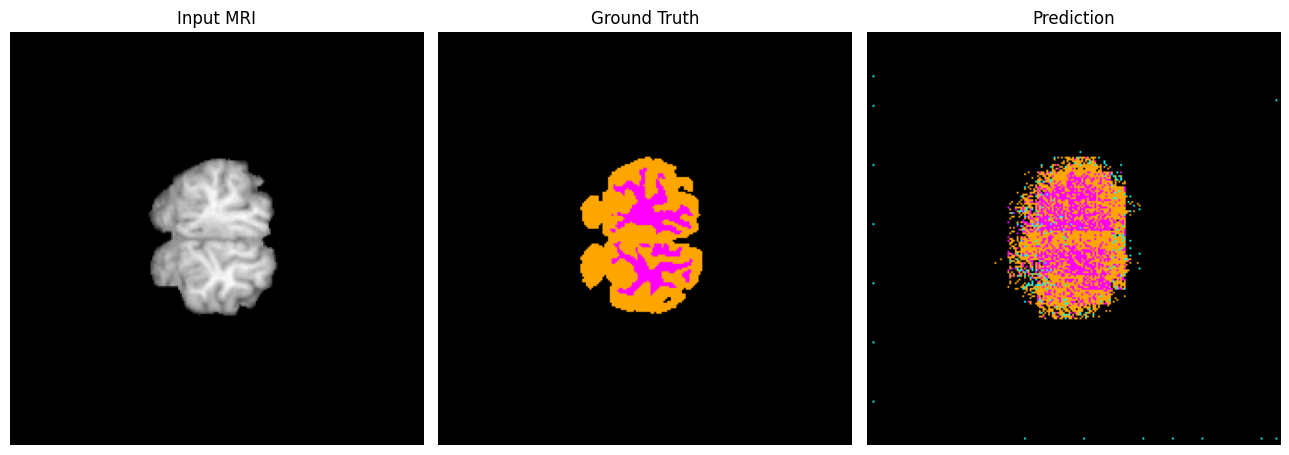

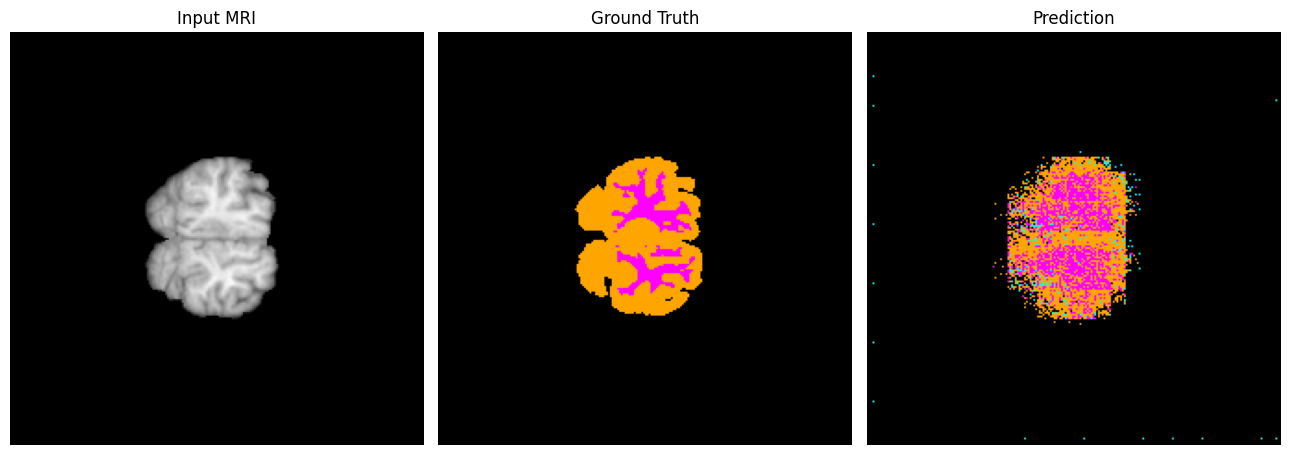

Prediction after epoch 70


Epoch 70: val_iou_score_multiclass improved from 0.40494 to 0.40531, saving model to best_model_fcn8s_multiclass_ibsr.keras

Epoch 70: finished saving model to best_model_fcn8s_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - csf_iou: 4.6348e-04 - dice_coefficient_multiclass: 0.4564 - gm_iou: 0.3739 - iou_score_multiclass: 0.3818 - loss: 0.5993 - pixel_accuracy_multiclass: 0.9830 - wm_iou: 0.1689 - val_csf_iou: 0.0067 - val_dice_coefficient_multiclass: 0.4932 - val_gm_iou: 0.3819 - val_iou_score_multiclass: 0.4053 - val_loss: 0.7126 - val_pixel_accuracy_multiclass: 0.9205 - val_wm_iou: 0.2713 - learning_rate: 1.0000e-04
Epoch 71/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - csf_iou: 0.0041 - dice_coefficient_multiclass: 0.4916 - gm_iou: 0.3904 - iou_score_multiclass: 0.4054 - loss: 0.6996 - pixel_accuracy_multiclass: 0.9252 - wm_iou: 0.2628
Epoch 71: val_iou_score_multiclass improved from 0.40531 to 0.40830, saving model to best_model_fcn8s_mu

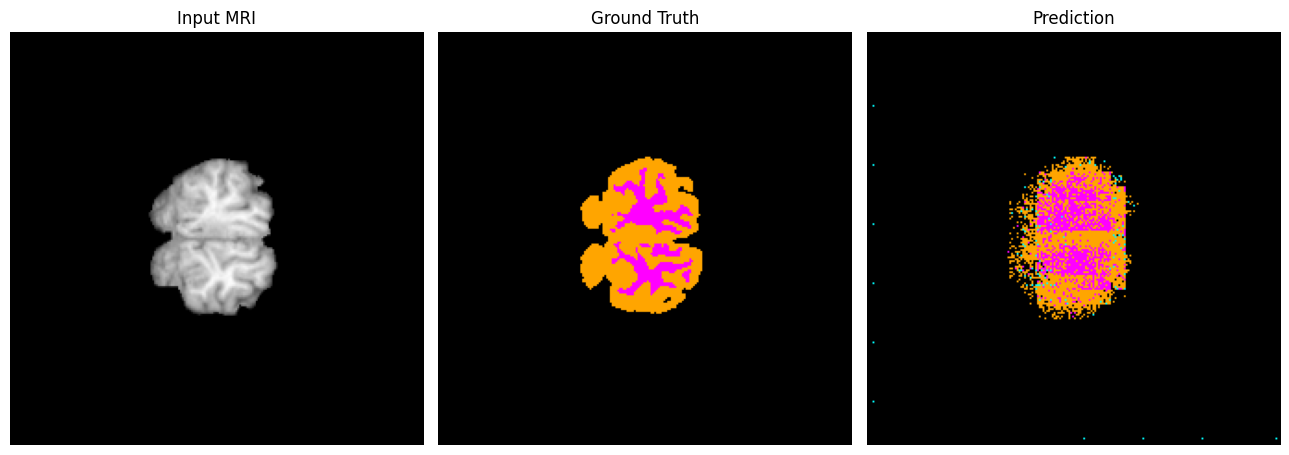

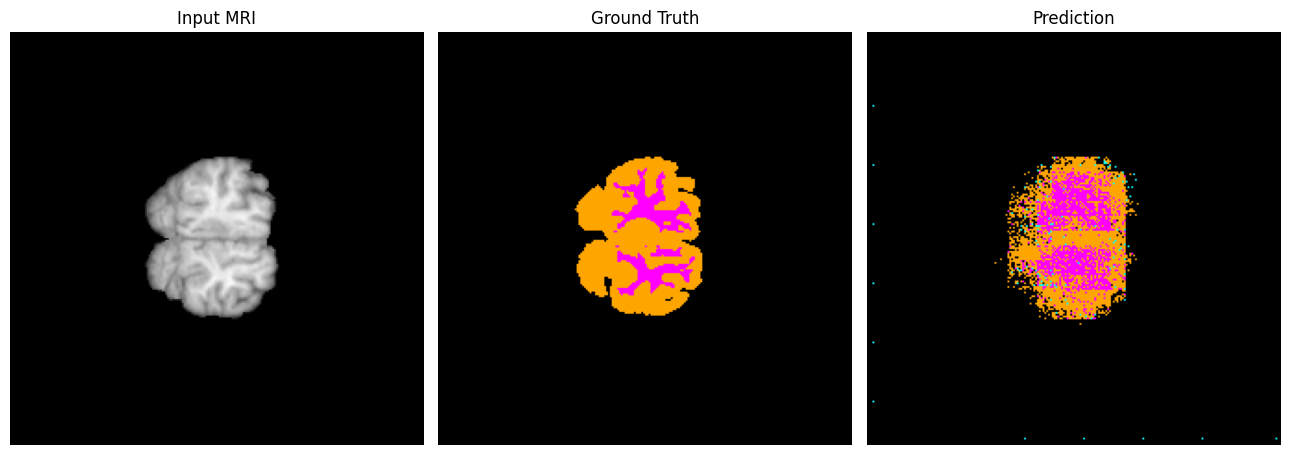

Prediction after epoch 80


Epoch 80: val_iou_score_multiclass improved from 0.42021 to 0.42198, saving model to best_model_fcn8s_multiclass_ibsr.keras

Epoch 80: finished saving model to best_model_fcn8s_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - csf_iou: 7.9116e-04 - dice_coefficient_multiclass: 0.4810 - gm_iou: 0.4224 - iou_score_multiclass: 0.4031 - loss: 0.5660 - pixel_accuracy_multiclass: 0.9857 - wm_iou: 0.2020 - val_csf_iou: 0.0076 - val_dice_coefficient_multiclass: 0.5116 - val_gm_iou: 0.4072 - val_iou_score_multiclass: 0.4220 - val_loss: 0.6733 - val_pixel_accuracy_multiclass: 0.9284 - val_wm_iou: 0.3077 - learning_rate: 1.0000e-04
Epoch 81/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - csf_iou: 0.0043 - dice_coefficient_multiclass: 0.5113 - gm_iou: 0.4193 - iou_score_multiclass: 0.4232 - loss: 0.6621 - pixel_accuracy_multiclass: 0.9325 - wm_iou: 0.3020
Epoch 81: val_iou_score_multiclass did not improve from 0.42198
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step -

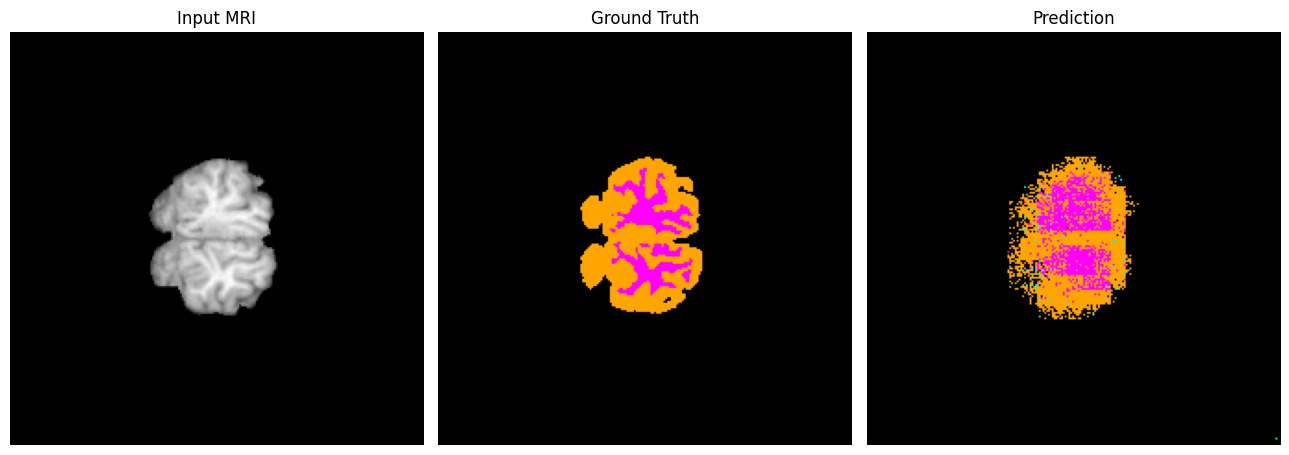

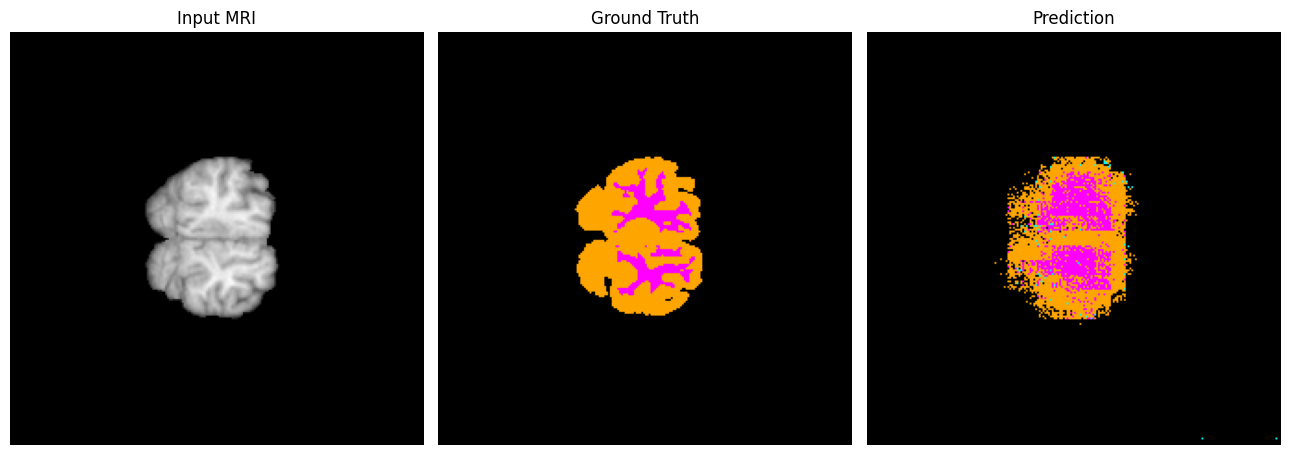

Prediction after epoch 90


Epoch 90: val_iou_score_multiclass improved from 0.43210 to 0.43260, saving model to best_model_fcn8s_multiclass_ibsr.keras

Epoch 90: finished saving model to best_model_fcn8s_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - csf_iou: 9.3110e-04 - dice_coefficient_multiclass: 0.4915 - gm_iou: 0.4387 - iou_score_multiclass: 0.4119 - loss: 0.5535 - pixel_accuracy_multiclass: 0.9862 - wm_iou: 0.2210 - val_csf_iou: 0.0084 - val_dice_coefficient_multiclass: 0.5231 - val_gm_iou: 0.4232 - val_iou_score_multiclass: 0.4326 - val_loss: 0.6491 - val_pixel_accuracy_multiclass: 0.9327 - val_wm_iou: 0.3318 - learning_rate: 1.0000e-04
Epoch 91/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - csf_iou: 0.0055 - dice_coefficient_multiclass: 0.5230 - gm_iou: 0.4405 - iou_score_multiclass: 0.4342 - loss: 0.6361 - pixel_accuracy_multiclass: 0.9377 - wm_iou: 0.3220
Epoch 91: val_iou_score_multiclass improved from 0.43260 to 0.43766, saving model to best_model_fcn8s_mu

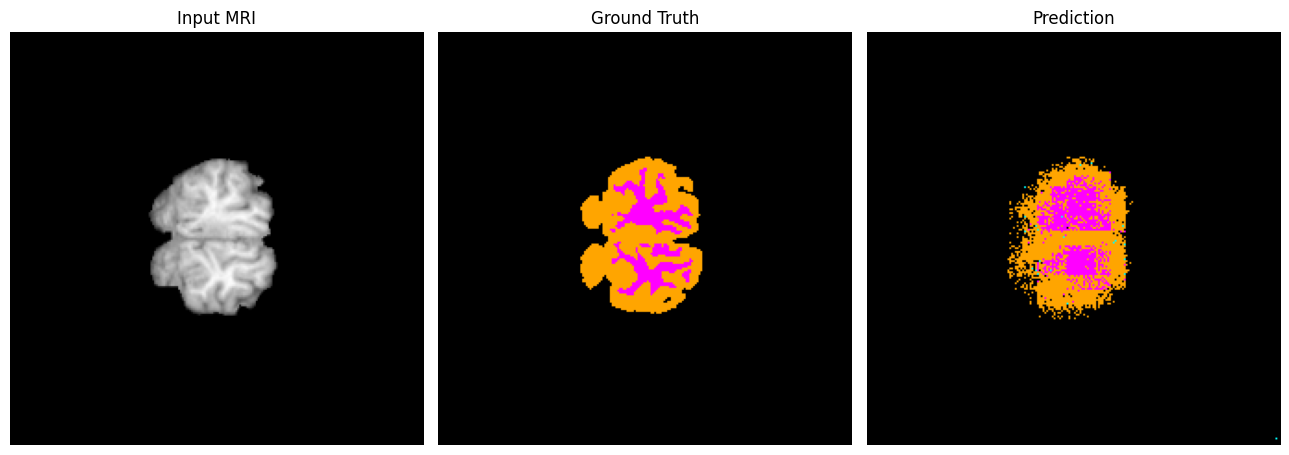

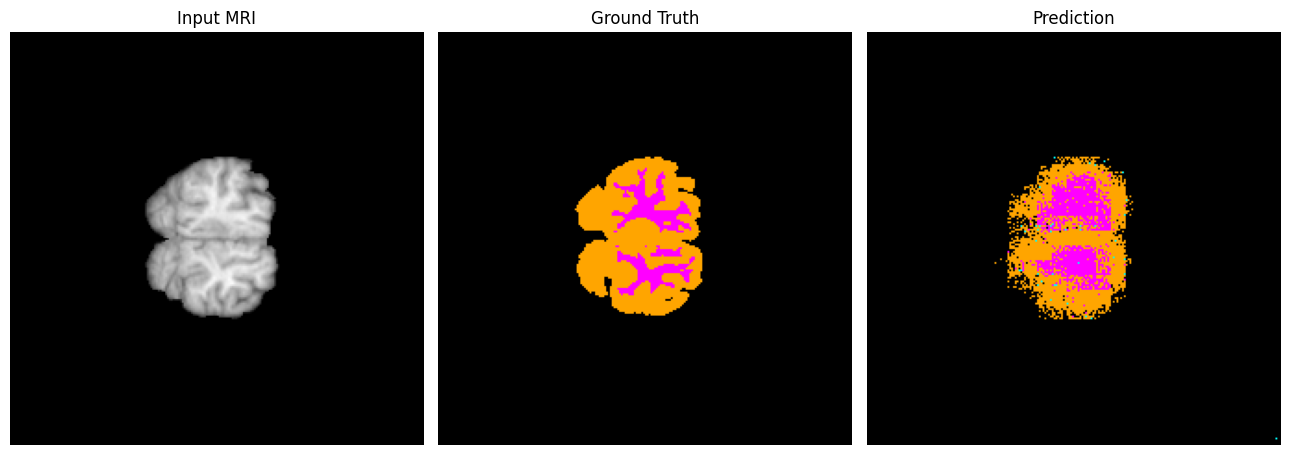

Prediction after epoch 100


Epoch 100: val_iou_score_multiclass did not improve from 0.44823
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - csf_iou: 0.0017 - dice_coefficient_multiclass: 0.5012 - gm_iou: 0.4650 - iou_score_multiclass: 0.4214 - loss: 0.5405 - pixel_accuracy_multiclass: 0.9870 - wm_iou: 0.2300 - val_csf_iou: 0.0111 - val_dice_coefficient_multiclass: 0.5390 - val_gm_iou: 0.4550 - val_iou_score_multiclass: 0.4479 - val_loss: 0.6182 - val_pixel_accuracy_multiclass: 0.9389 - val_wm_iou: 0.3551 - learning_rate: 1.0000e-04

Training time: 49.1 min


In [15]:
steps_per_epoch  = max(1, len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE)
validation_steps = max(1, len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE)
print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()
history = model.fit(
    train_dataset, validation_data=test_dataset, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks_list
)
elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed/60:.1f} min')


## 13. Training Graphs

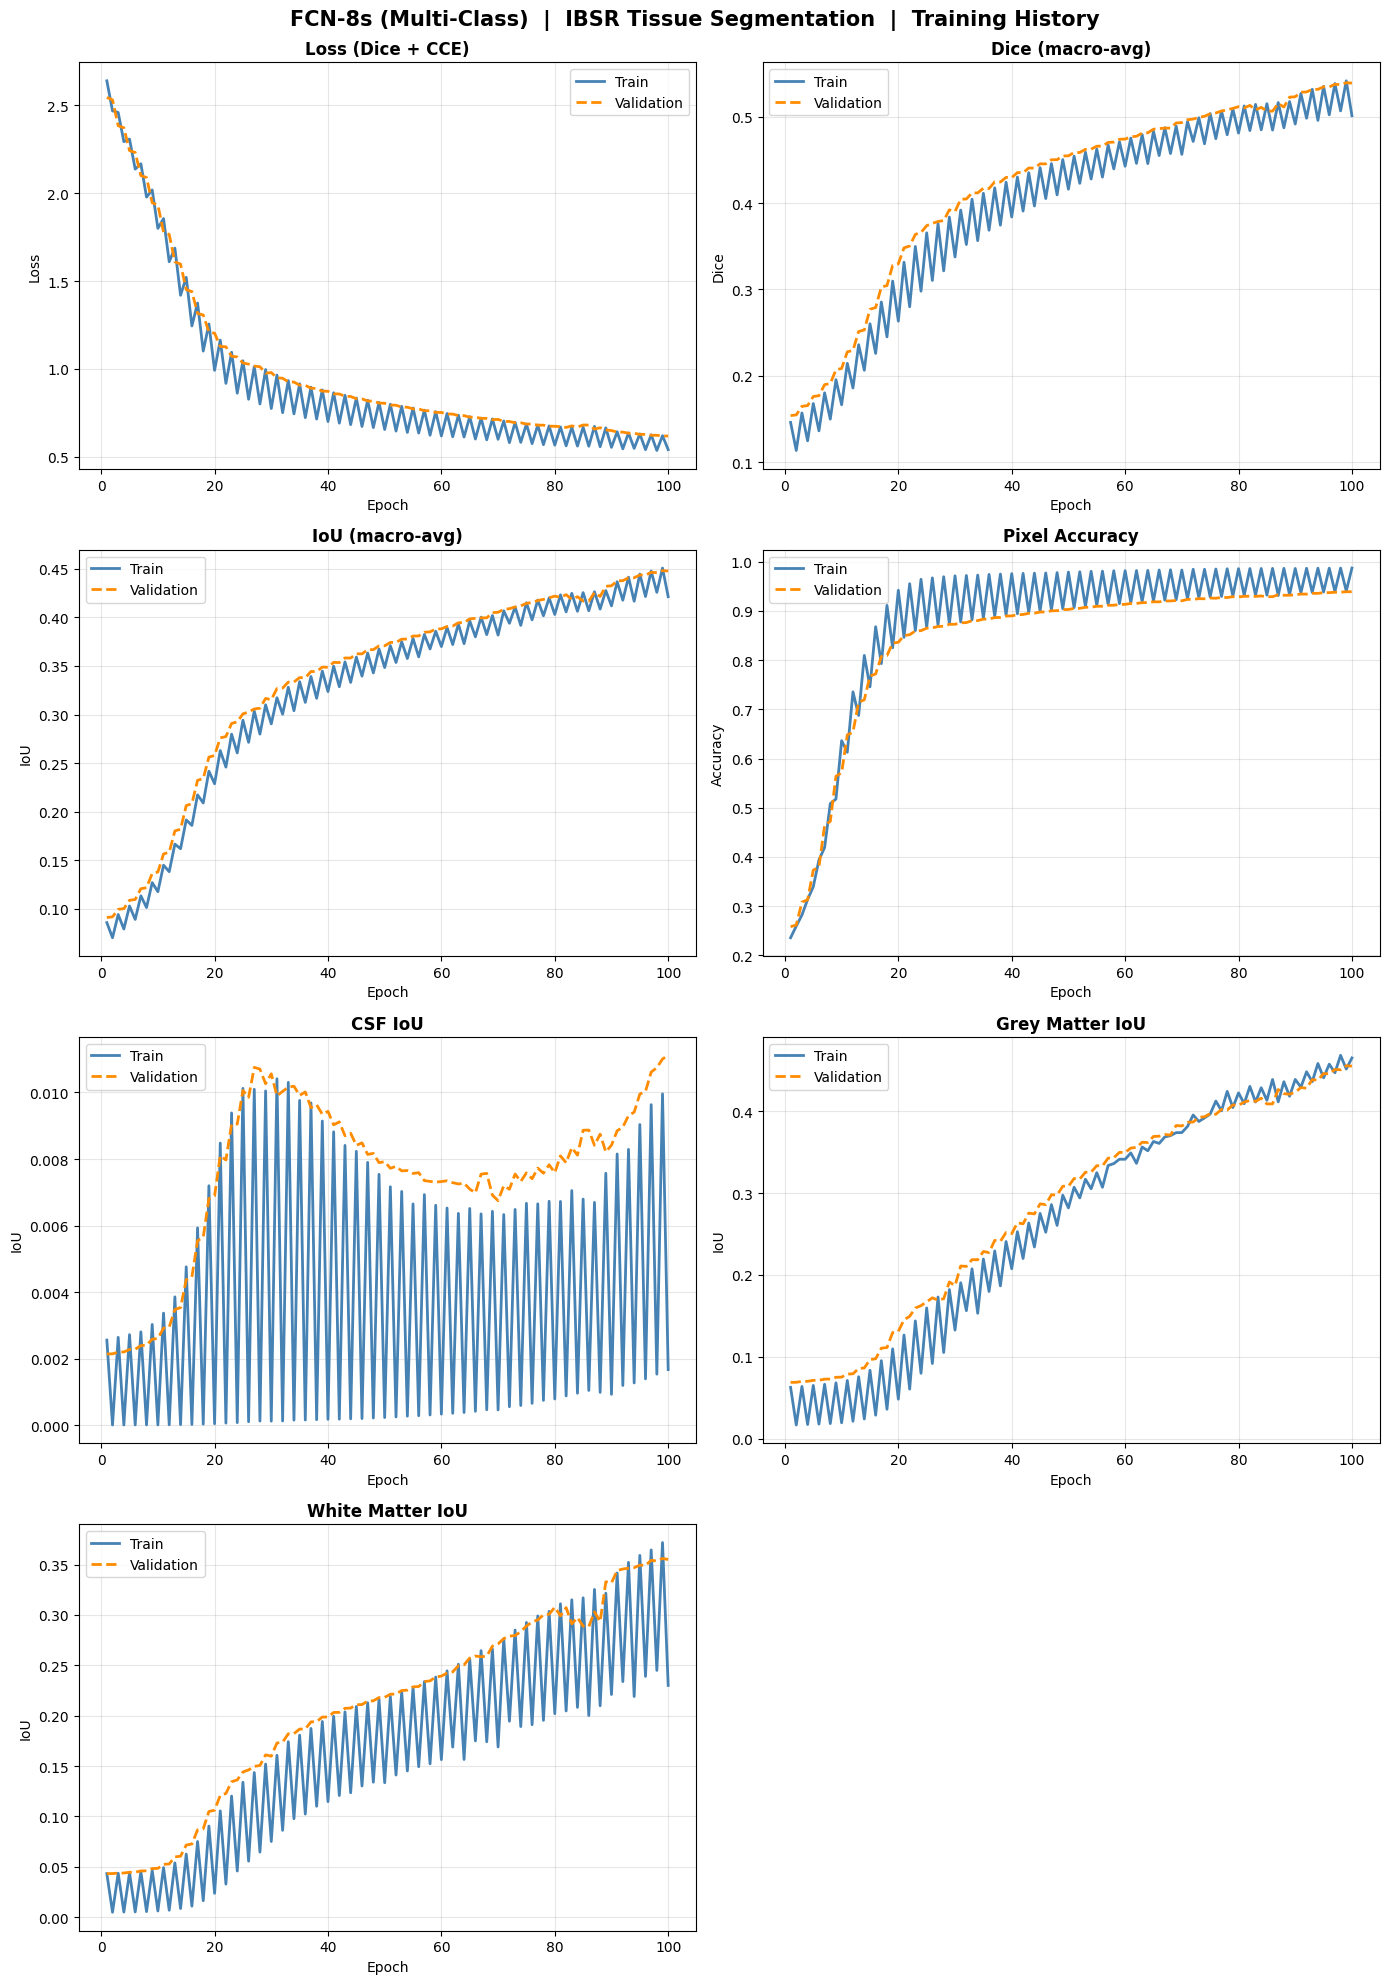

Plot saved ✓


In [16]:
H = history.history

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('FCN-8s (Multi-Class)  |  IBSR Tissue Segmentation  |  Training History',
             fontsize=15, fontweight='bold', y=0.99)

plot_specs = [
    ('loss', 'val_loss', 'Loss (Dice + CCE)', 'Loss'),
    ('dice_coefficient_multiclass', 'val_dice_coefficient_multiclass', 'Dice (macro-avg)', 'Dice'),
    ('iou_score_multiclass', 'val_iou_score_multiclass', 'IoU (macro-avg)', 'IoU'),
    ('pixel_accuracy_multiclass', 'val_pixel_accuracy_multiclass', 'Pixel Accuracy', 'Accuracy'),
    ('csf_iou', 'val_csf_iou', 'CSF IoU', 'IoU'),
    ('gm_iou', 'val_gm_iou', 'Grey Matter IoU', 'IoU'),
    ('wm_iou', 'val_wm_iou', 'White Matter IoU', 'IoU'),
]

for ax, (train_key, val_key, title, ylabel) in zip(axes.flatten(), plot_specs):
    epochs_range = range(1, len(H[train_key]) + 1)
    ax.plot(epochs_range, H[train_key], label='Train', color='steelblue', linewidth=2)
    ax.plot(epochs_range, H[val_key], label='Validation', color='darkorange', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('training_history_fcn8s_multiclass_ibsr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')


## 14. Best & Average Metrics Table

In [17]:
metric_spec = [
    ('Loss', 'loss', 'min'),
    ('Dice (macro-avg)', 'dice_coefficient_multiclass', 'max'),
    ('IoU (macro-avg)', 'iou_score_multiclass', 'max'),
    ('Pixel Accuracy', 'pixel_accuracy_multiclass', 'max'),
    ('CSF IoU', 'csf_iou', 'max'),
    ('Grey Matter IoU', 'gm_iou', 'max'),
    ('White Matter IoU', 'wm_iou', 'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key], dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({'Metric': disp, 'Train Best': pick(tr), 'Train Avg': tr.mean(),
                 'Val Best': pick(va), 'Val Avg': va.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)
print('=' * 70)
print('   BEST & AVERAGE METRICS  —  FCN-8s Multi-Class  |  IBSR')
print('=' * 70)
print(report.to_string())
print('=' * 70)

best_epoch_iou = int(np.argmax(H['val_iou_score_multiclass'])) + 1
print(f'\nBest Val IoU (macro-avg): {max(H["val_iou_score_multiclass"]):.4f}  (epoch {best_epoch_iou})')
print(f'Best Val CSF IoU         : {max(H["val_csf_iou"]):.4f}')
print(f'Best Val Grey Matter IoU : {max(H["val_gm_iou"]):.4f}')
print(f'Best Val White Matter IoU: {max(H["val_wm_iou"]):.4f}')
report


   BEST & AVERAGE METRICS  —  FCN-8s Multi-Class  |  IBSR
                  Train Best  Train Avg  Val Best  Val Avg
Metric                                                    
Loss                  0.5356     0.9362    0.6180   0.9970
Dice (macro-avg)      0.5416     0.3965    0.5393   0.4193
IoU (macro-avg)       0.4509     0.3249    0.4482   0.3378
Pixel Accuracy        0.9870     0.8741    0.9389   0.8418
CSF IoU               0.0104     0.0038    0.0111   0.0076
Grey Matter IoU       0.4682     0.2643    0.4555   0.2815
White Matter IoU      0.3719     0.1669    0.3561   0.2090

Best Val IoU (macro-avg): 0.4482  (epoch 99)
Best Val CSF IoU         : 0.0111
Best Val Grey Matter IoU : 0.4555
Best Val White Matter IoU: 0.3561


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.5356,0.9362,0.6180,0.9970
Dice (macro-avg),0.5416,0.3965,0.5393,0.4193
IoU (macro-avg),0.4509,0.3249,0.4482,0.3378
Pixel Accuracy,0.9870,0.8741,0.9389,0.8418
CSF IoU,0.0104,0.0038,0.0111,0.0076
Grey Matter IoU,0.4682,0.2643,0.4555,0.2815
White Matter IoU,0.3719,0.1669,0.3561,0.2090


## 15. Load Best Model & Final Evaluation

In [18]:
best_model = tf.keras.models.load_model(
    'best_model_fcn8s_multiclass_ibsr.keras',
    custom_objects={
        'combined_loss_multiclass': combined_loss_multiclass,
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_score_multiclass': iou_score_multiclass,
        'pixel_accuracy_multiclass': pixel_accuracy_multiclass,
        'csf_iou': csf_iou, 'gm_iou': gm_iou, 'wm_iou': wm_iou,
    }
)
print('Best model loaded ✓')


Best model loaded ✓


In [19]:
print('Evaluating best model on held-out test set...\n')
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict = dict(zip(best_model.metrics_names, test_results))

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (FCN-8s Multi-Class | IBSR)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {k:35s}: {v:.4f}')
print('=' * 60)

final_df = pd.DataFrame([{
    'Model': 'FCN-8s Multi-Class (IBSR)',
    'IoU (macro)': round(test_dict.get('iou_score_multiclass', float('nan')), 4),
    'Dice (macro)': round(test_dict.get('dice_coefficient_multiclass', float('nan')), 4),
    'CSF IoU': round(test_dict.get('csf_iou', float('nan')), 4),
    'GM IoU': round(test_dict.get('gm_iou', float('nan')), 4),
    'WM IoU': round(test_dict.get('wm_iou', float('nan')), 4),
    'Pixel Accuracy': round(test_dict.get('pixel_accuracy_multiclass', float('nan')), 4),
}]).set_index('Model')
final_df


Evaluating best model on held-out test set...

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - csf_iou: 0.0081 - dice_coefficient_multiclass: 0.5328 - gm_iou: 0.4503 - iou_score_multiclass: 0.4435 - loss: 0.6108 - pixel_accuracy_multiclass: 0.9513 - wm_iou: 0.3410 

  FINAL TEST-SET METRICS  (FCN-8s Multi-Class | IBSR)
  loss                               : 0.6108
  compile_metrics                    : 0.5328


,IoU (macro),Dice (macro),CSF IoU,GM IoU,WM IoU,Pixel Accuracy
Model,,,,,,
FCN-8s Multi-Class (IBSR),NaN,NaN,NaN,NaN,NaN,NaN


## 16. Test Predictions Visualization

Test set predictions:


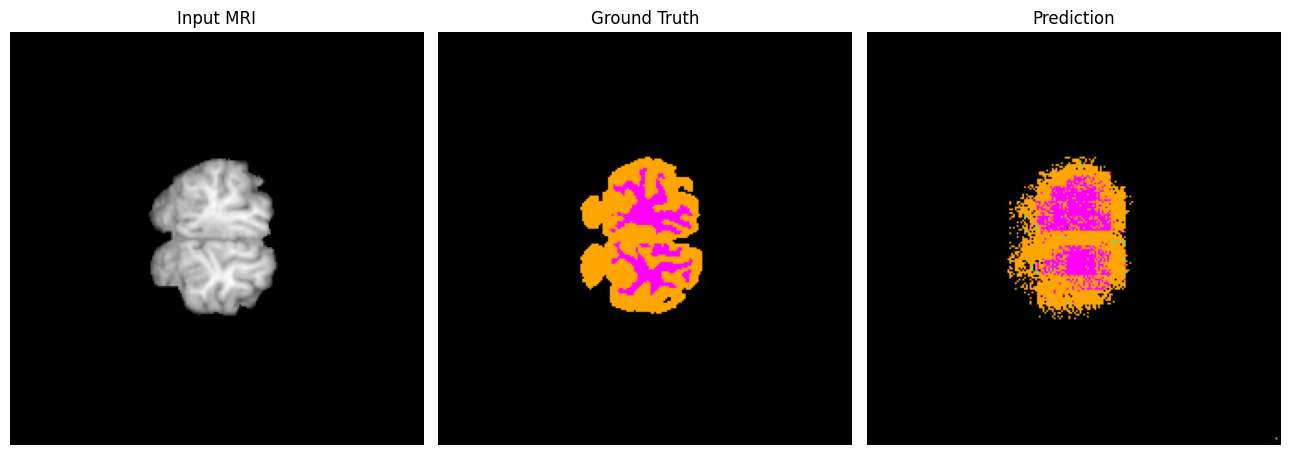

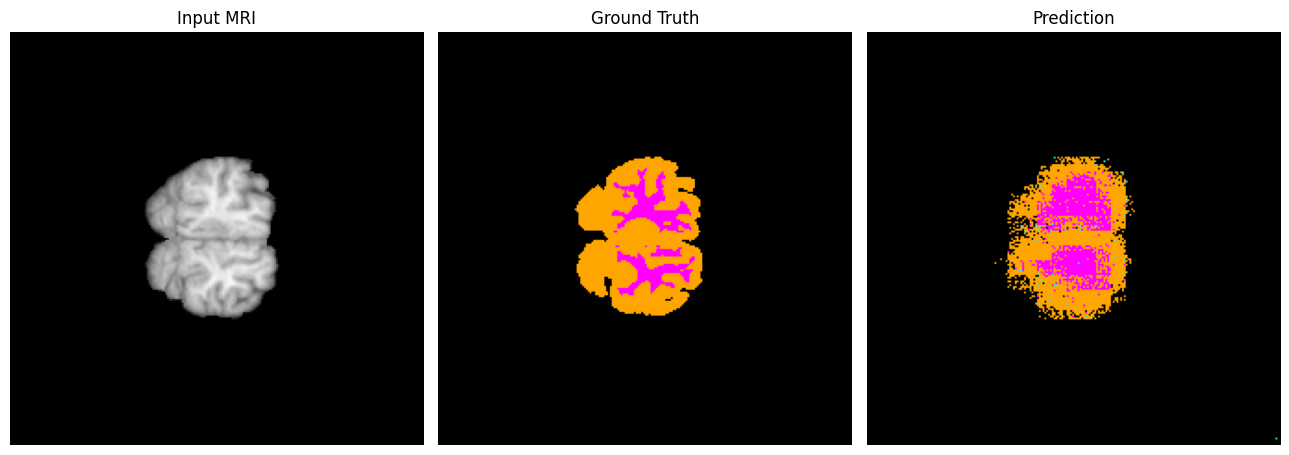

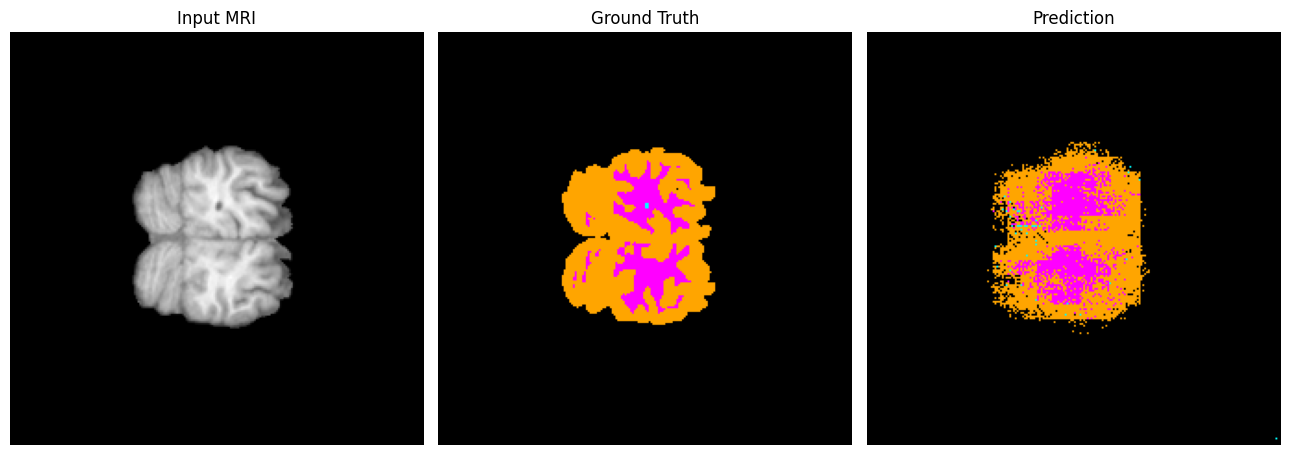

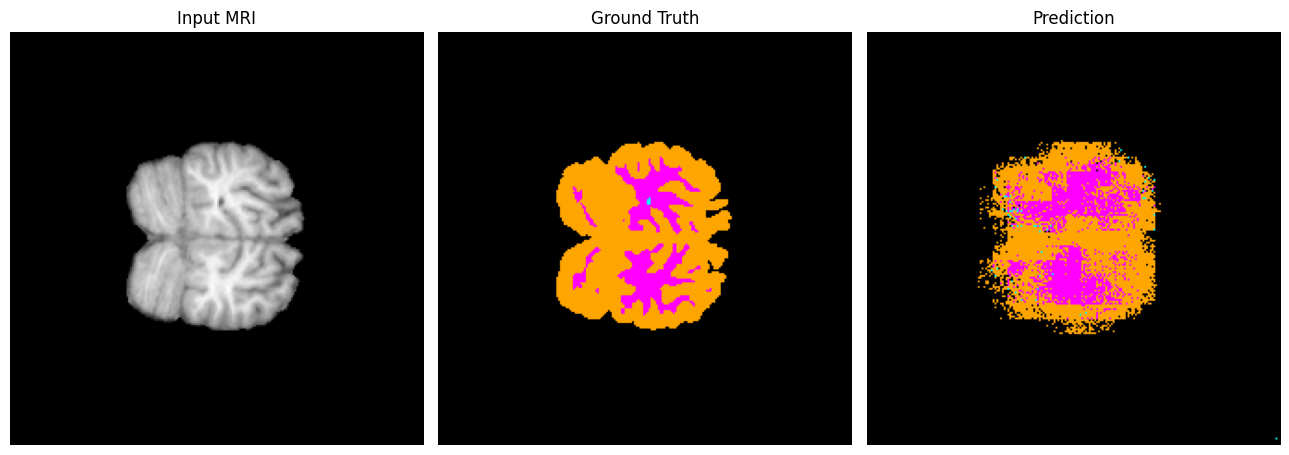

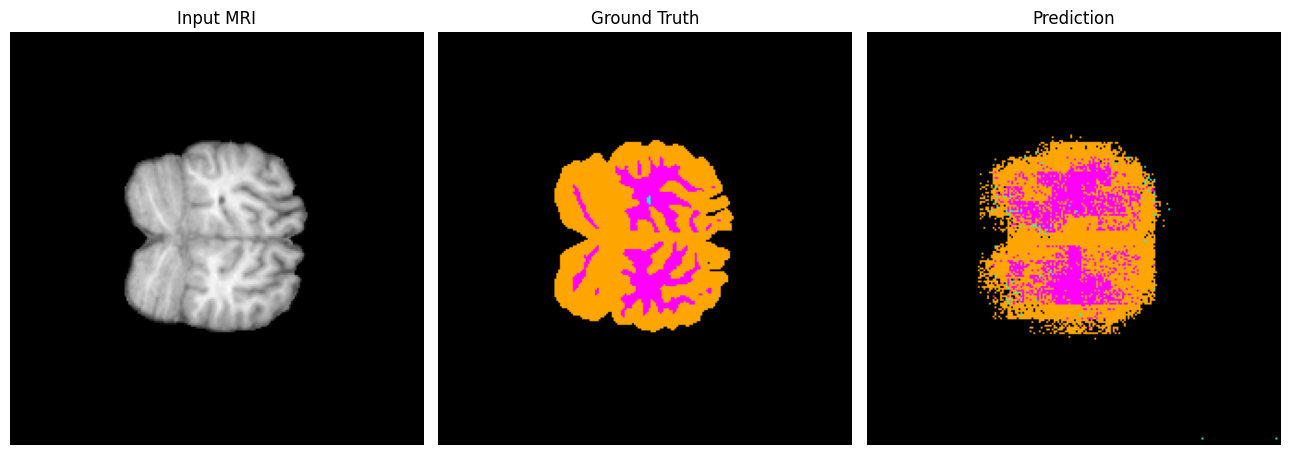

In [20]:
print('Test set predictions:')
show_predictions(test_dataset, num=5, model_to_use=best_model)


## 17. Save Final Model

In [21]:
best_model.save('ibsr_fcn8s_multiclass_final.keras')
print('Model saved ✓')


Model saved ✓
